In [ ]:
!pip uninstall -y numpy pandas scikit-learn xgboost shap lightgbm catboost

In [ ]:
!pip install "numpy<2.0" pandas scikit-learn xgboost shap lightgbm catboost

In [ ]:
!pip install --upgrade numexpr bottleneck

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

In [3]:
data=pd.read_csv(r"marketing.csv")
data

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,result
0,13829,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,-1,0,unknown,no
1,22677,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,-1,0,unknown,no
2,10541,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,-1,0,unknown,no
3,13689,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,-1,0,unknown,no
4,11304,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,14023,47,technician,married,secondary,no,1167,yes,no,cellular,30,apr,1,87,5,failure,yes
12866,17259,31,unknown,married,secondary,no,111,no,no,cellular,21,nov,2,93,2,failure,yes
12867,15200,37,unemployed,single,tertiary,no,1316,yes,no,cellular,18,nov,1,172,2,failure,no
12868,13775,42,management,married,tertiary,no,479,yes,no,unknown,28,may,2,-1,0,unknown,no


In [4]:
pd.set_option('display.max_columns',None)
data.describe(include='all')

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,result
count,12870.000000,12870.000000,12870,12870,12870,12870,12870.000000,12870,12870,12870,12870.000000,12870,12870.000000,12870.000000,12870.000000,12870,12870
unique,NaN,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,4,2
top,NaN,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,unknown,no
freq,NaN,NaN,2858,7490,6368,12662,NaN,6605,11060,8756,NaN,3594,NaN,NaN,NaN,10070,8903
mean,16434.500000,41.091142,NaN,NaN,NaN,NaN,1483.774437,NaN,NaN,NaN,15.641103,NaN,2.659130,45.555478,0.688967,NaN,NaN
std,3715.393317,11.305560,NaN,NaN,NaN,NaN,3311.055181,NaN,NaN,NaN,8.368983,NaN,2.863507,104.449411,2.049696,NaN,NaN
min,10000.000000,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,-1.000000,0.000000,NaN,NaN
25%,13217.250000,32.000000,NaN,NaN,NaN,NaN,102.000000,NaN,NaN,NaN,8.000000,NaN,1.000000,-1.000000,0.000000,NaN,NaN
50%,16434.500000,39.000000,NaN,NaN,NaN,NaN,515.000000,NaN,NaN,NaN,16.000000,NaN,2.000000,-1.000000,0.000000,NaN,NaN
75%,19651.750000,49.000000,NaN,NaN,NaN,NaN,1591.750000,NaN,NaN,NaN,21.000000,NaN,3.000000,-1.000000,0.000000,NaN,NaN


In [5]:
data.dtypes

ID           int64
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
campaign     int64
pdays        int64
previous     int64
response       str
result         str
dtype: object

In [6]:
data = data.drop(['ID', 'pdays', 'previous'], axis=1)
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,response,result
0,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,unknown,no
1,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,unknown,no
2,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,unknown,no
3,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,unknown,no
4,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,unknown,no


In [7]:
a={
    "yes":0,
    "no":1
}
data["result"]=data["result"].map(a)
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,response,result
0,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,unknown,1
1,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,unknown,1
2,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,unknown,1
3,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,unknown,1
4,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,47,technician,married,secondary,no,1167,yes,no,cellular,30,apr,1,failure,0
12866,31,unknown,married,secondary,no,111,no,no,cellular,21,nov,2,failure,0
12867,37,unemployed,single,tertiary,no,1316,yes,no,cellular,18,nov,1,failure,1
12868,42,management,married,tertiary,no,479,yes,no,unknown,28,may,2,unknown,1


In [8]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
response     0
result       0
dtype: int64

In [9]:
bins = [18, 30, 45, 60, 100]
labels = ['Young', 'Middle-Aged', 'Senior', 'Elderly']
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)

In [10]:
data['job_avg_balance'] = data.groupby('job')['balance'].transform('mean')

In [11]:
data['balance_diff_job'] = data['balance'] - data['job_avg_balance']

In [12]:
data_lr=data.copy()
data_knn=data.copy()

In [13]:
new_data = data.copy()
from sklearn.preprocessing import LabelEncoder

encoders = {}
for i in new_data.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    new_data[i] = le.fit_transform(new_data[i].astype(str)) 
    encoders[i] = le

new_data.head()

C:\Users\User\AppData\Local\Temp\ipykernel_11052\4037223739.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in new_data.select_dtypes(include=['object', 'category']).columns:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,response,result,age_group,job_avg_balance,balance_diff_job
0,29,9,2,2,0,18254,0,0,0,11,8,2,3,1,3,1317.000000,16937.000000
1,26,7,2,1,0,512,1,1,2,5,6,3,3,1,3,979.535954,-467.535954
2,30,4,2,1,0,135,0,0,0,14,1,2,3,1,1,1970.496851,-1835.496851
3,41,9,1,3,0,30,1,0,0,10,5,1,3,1,1,1317.000000,-1287.000000
4,27,0,2,1,0,321,0,1,2,2,11,1,3,1,3,1249.092896,-928.092896


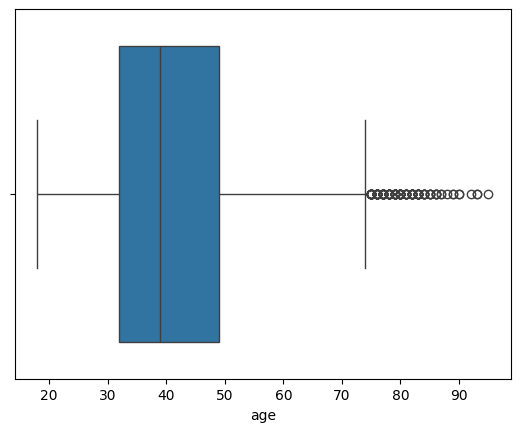

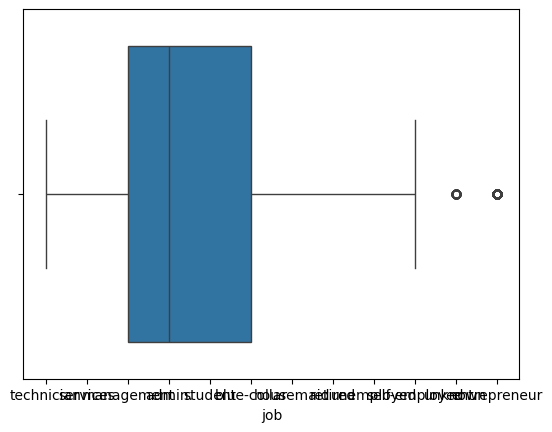

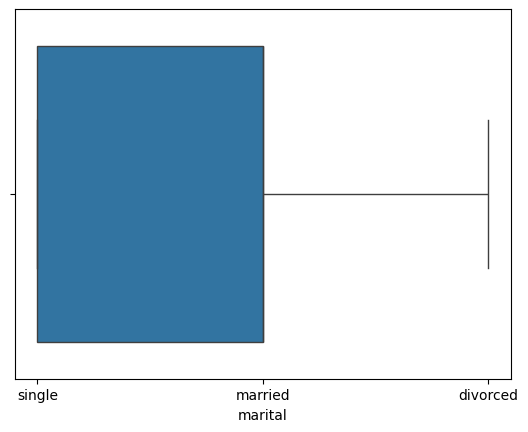

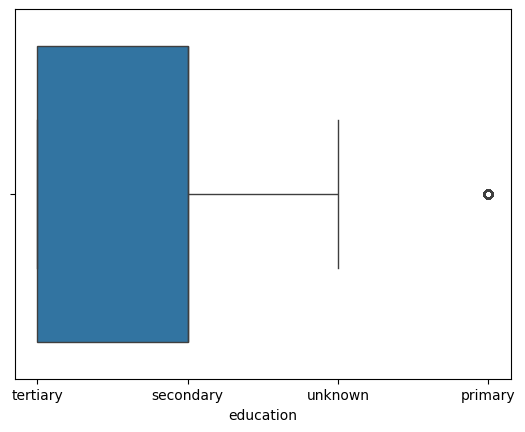

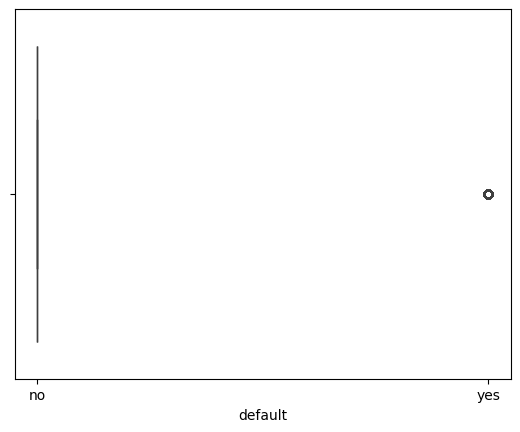

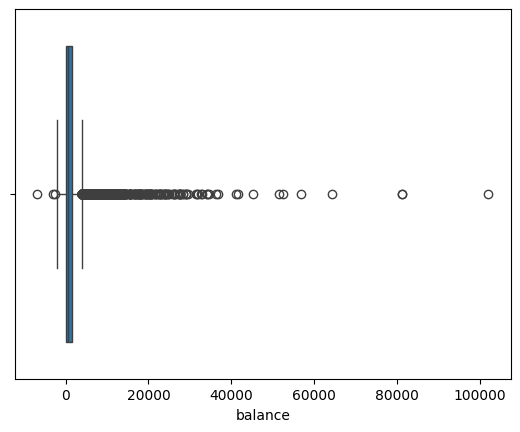

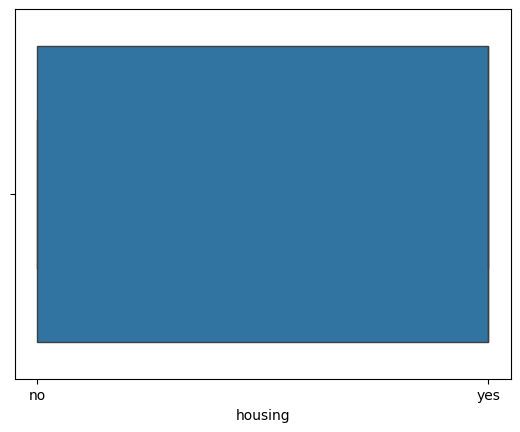

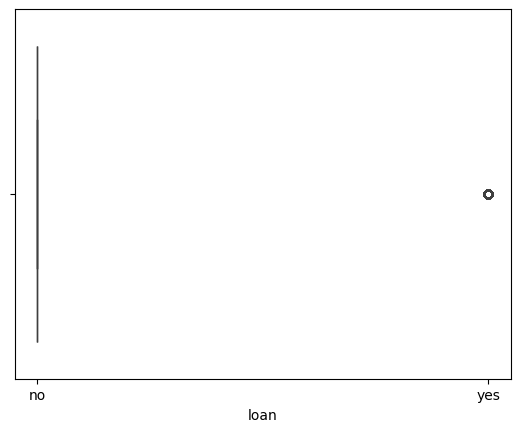

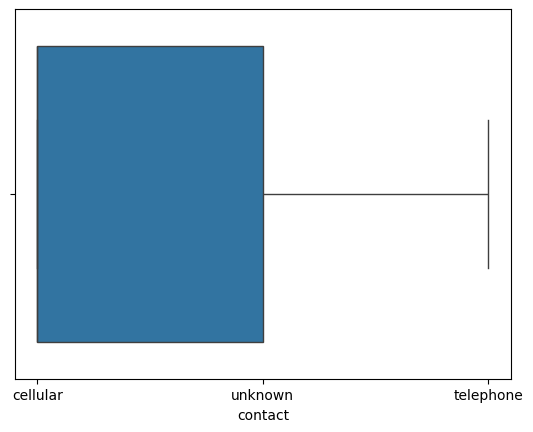

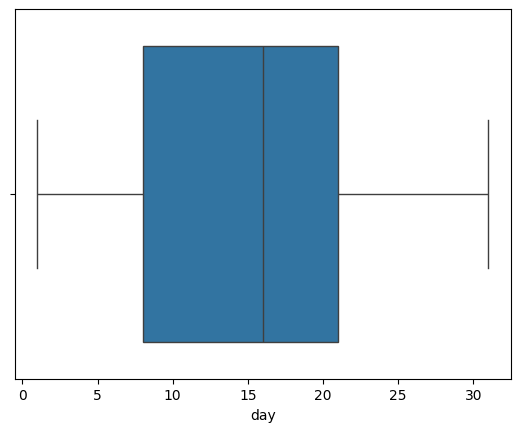

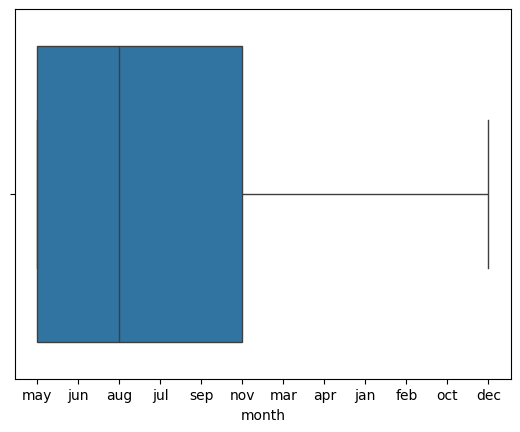

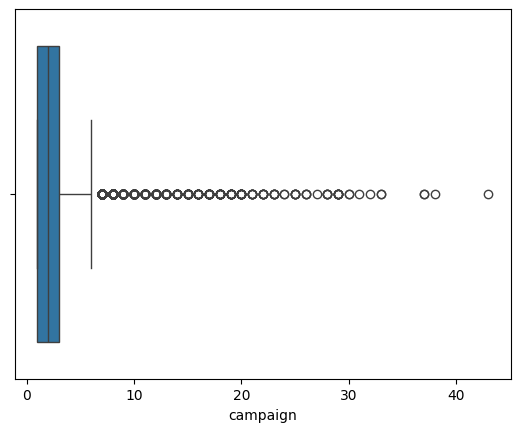

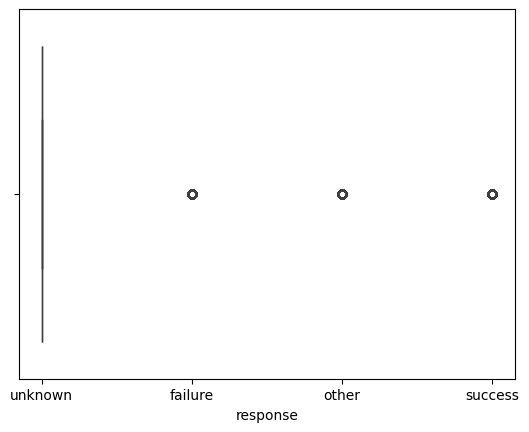

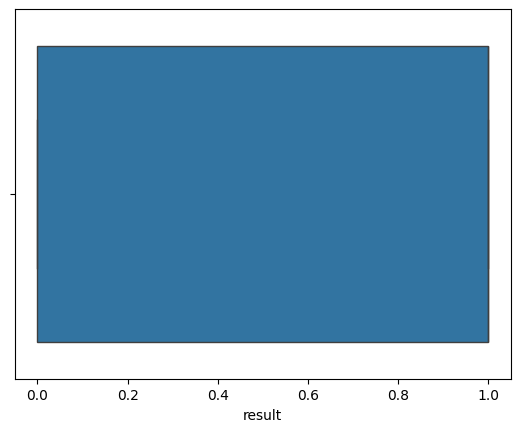

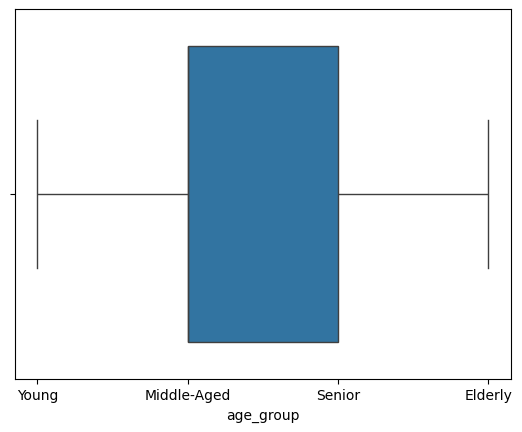

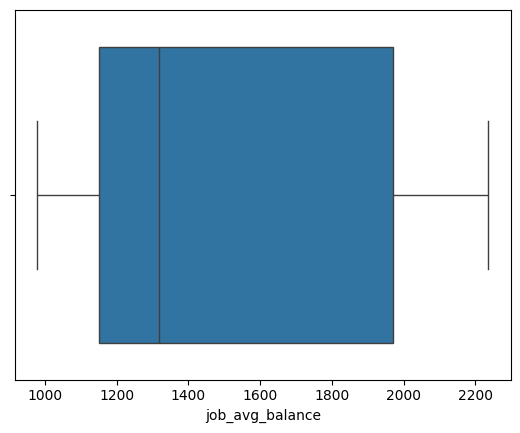

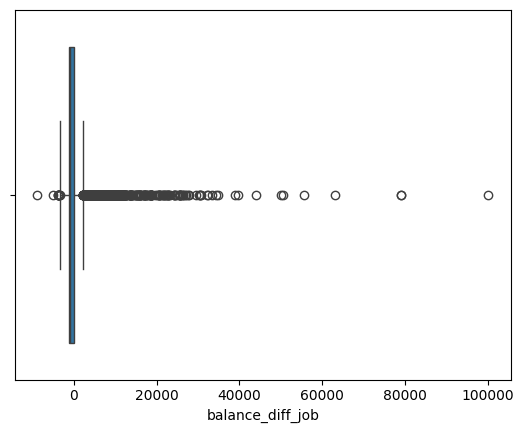

In [14]:
for i in data_knn.columns:
    if data_knn[i].dtypes!=object:
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()

In [15]:
q1=data_knn.quantile(0.25, numeric_only=True)
q3=data_knn.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

In [16]:
data_knn['age_group']=data_knn['age_group'].astype(str)

In [17]:
data_knn.dtypes

age                   int64
job                     str
marital                 str
education               str
default                 str
balance               int64
housing                 str
loan                    str
contact                 str
day                   int64
month                   str
campaign              int64
response                str
result                int64
age_group               str
job_avg_balance     float64
balance_diff_job    float64
dtype: object

In [18]:
data_knn

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,response,result,age_group,job_avg_balance,balance_diff_job
0,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,unknown,1,Young,1317.000000,16937.000000
1,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,unknown,1,Young,979.535954,-467.535954
2,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,unknown,1,Middle-Aged,1970.496851,-1835.496851
3,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,unknown,1,Middle-Aged,1317.000000,-1287.000000
4,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,unknown,1,Young,1249.092896,-928.092896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,47,technician,married,secondary,no,1167,yes,no,cellular,30,apr,1,failure,0,Senior,1317.000000,-150.000000
12866,31,unknown,married,secondary,no,111,no,no,cellular,21,nov,2,failure,0,Middle-Aged,1470.337500,-1359.337500
12867,37,unemployed,single,tertiary,no,1316,yes,no,cellular,18,nov,1,failure,1,Middle-Aged,1588.758454,-272.758454
12868,42,management,married,tertiary,no,479,yes,no,unknown,28,may,2,unknown,1,Middle-Aged,1970.496851,-1491.496851


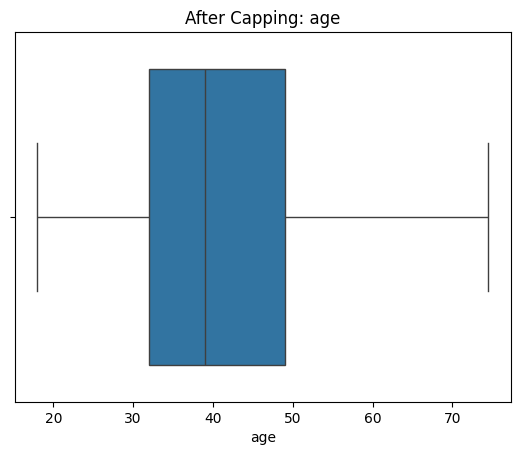

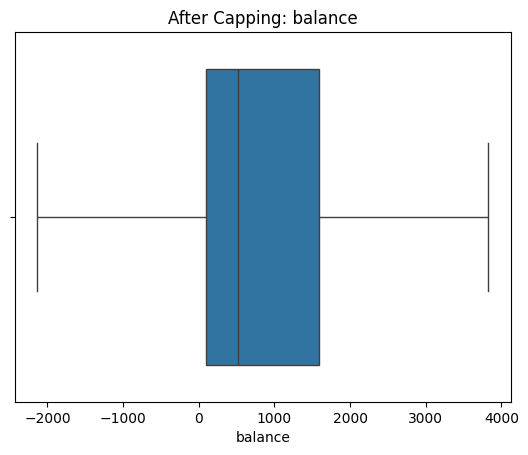

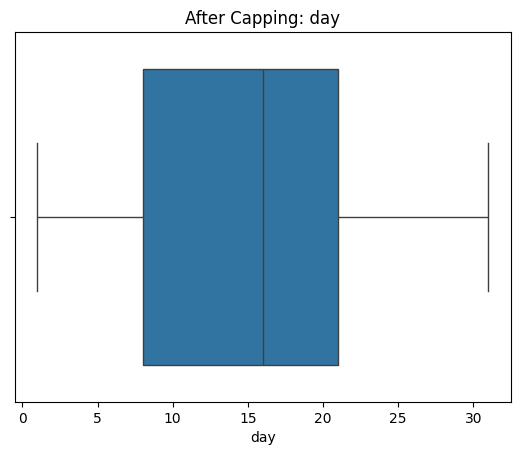

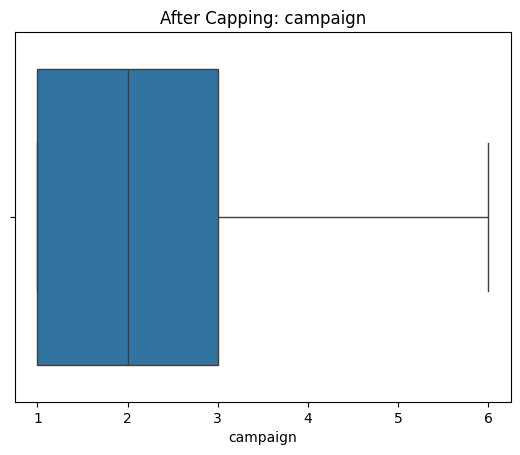

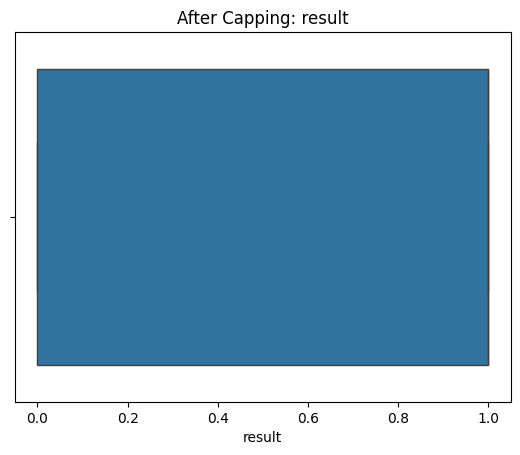

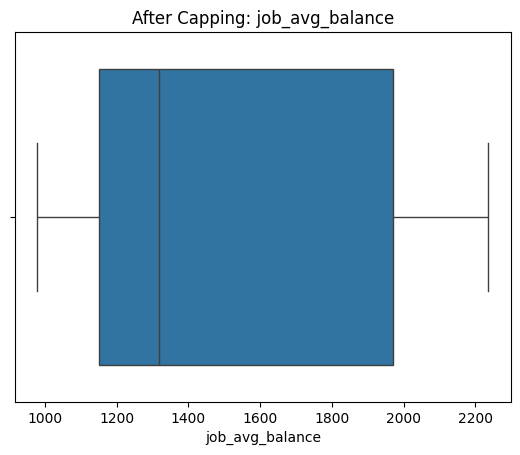

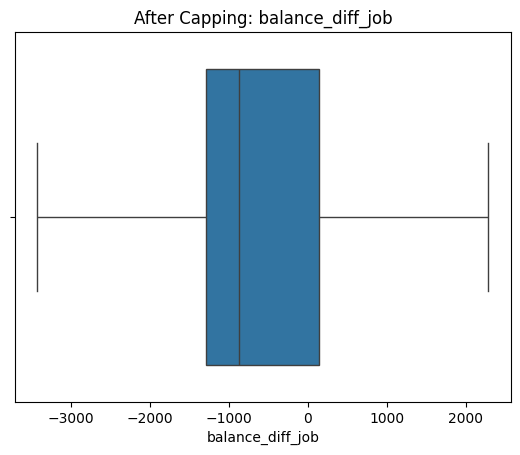

In [19]:
for i in data_knn.columns:
    if data_knn[i].dtypes != object and i in Upper.index:
        data_knn[i] = np.where(data_knn[i] > Upper[i], Upper[i], data_knn[i])
        data_knn[i] = np.where(data_knn[i] < Lower[i], Lower[i], data_knn[i])
        
        sns.boxplot(data=data_knn, x=data_knn[i])
        plt.title(f"After Capping: {i}")
        plt.show()

In [20]:
from scipy import stats

for i in data_knn.columns:
    
    if data_knn[i].dtype in ['int64', 'float64']:
        
        kstest_statistic, kstest_p_value = stats.kstest(data_knn[i], 'norm')
        
       
        
        print(f'Column: {i}')
        print(f'p-value: {kstest_p_value}')
        
        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

Column: age
p-value: 0.0
Data does not look normally distributed

Column: balance
p-value: 0.0
Data does not look normally distributed

Column: day
p-value: 0.0
Data does not look normally distributed

Column: campaign
p-value: 0.0
Data does not look normally distributed

Column: result
p-value: 0.0
Data does not look normally distributed

Column: job_avg_balance
p-value: 0.0
Data does not look normally distributed

Column: balance_diff_job
p-value: 0.0
Data does not look normally distributed



In [21]:
def target_correlation(data, target, threshold=0.1):
    
    corr_matrix = data.corr(method='spearman', numeric_only=True)
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target


target_result = target_correlation(data_knn, 'result')

target_result

,Variable,Correlation with Target
0,balance,-0.139456
1,campaign,0.121709
2,job_avg_balance,-0.132861


In [22]:
def intercorrelation(data, target, threshold=0.7):
    
    corr_matrix = data.corr(method='spearman',numeric_only=True)
    
    highly_correlated_variables = (np.abs(corr_matrix) > threshold) & (corr_matrix != 1.0)
    
    independent_variable_pairs = np.where(highly_correlated_variables)
    
    correlated_pairs_set = set()
   
    for var1, var2 in zip(independent_variable_pairs[0], independent_variable_pairs[1]):

        if var1 < var2:
            correlated_pairs_set.add((corr_matrix.index[var1], corr_matrix.columns[var2]))
        else:
            correlated_pairs_set.add((corr_matrix.index[var2], corr_matrix.columns[var1]))
    
    result_intercorrelated_independent = pd.DataFrame(list(correlated_pairs_set), columns=['Variable 1', 'Variable 2'])
    
    return result_intercorrelated_independent

intercorrelated_result = intercorrelation(data_knn, 'result')
intercorrelated_result

,Variable 1,Variable 2
0,balance,balance_diff_job


In [23]:
target_result.Variable.tolist()

['balance', 'campaign', 'job_avg_balance']

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data, variables):
    vif_data = data_knn[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data, [
                                            'balance', 
    'campaign', 'job_avg_balance'                                 ])

vif_result


,VIF,Features
0,1.688229,balance
1,2.801773,campaign
2,3.494090,job_avg_balance


In [25]:
for i in data_knn.columns:
    if data_knn[i].dtype in ['int64', 'float64']:
        print(i)

age
balance
day
campaign
result
job_avg_balance
balance_diff_job


In [26]:
data_knn = data_knn.drop(["age","day","balance_diff_job"], axis=1)
data_knn.head()

,job,marital,education,default,balance,housing,loan,contact,month,campaign,response,result,age_group,job_avg_balance
0,technician,single,tertiary,no,3826.375,no,no,cellular,may,2.0,unknown,1.0,Young,1317.000000
1,services,single,secondary,no,512.000,yes,yes,unknown,jun,3.0,unknown,1.0,Young,979.535954
2,management,single,secondary,no,135.000,no,no,cellular,aug,2.0,unknown,1.0,Middle-Aged,1970.496851
3,technician,married,unknown,no,30.000,yes,no,cellular,jul,1.0,unknown,1.0,Middle-Aged,1317.000000
4,admin.,single,secondary,no,321.000,no,yes,unknown,sep,1.0,unknown,1.0,Young,1249.092896


In [27]:
data_knn = pd.get_dummies(data_knn, drop_first=True, dtype=int)

data_knn

,balance,campaign,result,job_avg_balance,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,response_other,response_success,response_unknown,age_group_Middle-Aged,age_group_Senior,age_group_Young
0,3826.375,2.0,1.0,1317.000000,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1
1,512.000,3.0,1.0,979.535954,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
2,135.000,2.0,1.0,1970.496851,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
3,30.000,1.0,1.0,1317.000000,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0
4,321.000,1.0,1.0,1249.092896,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,1167.000,1.0,0.0,1317.000000,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
12866,111.000,2.0,0.0,1470.337500,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
12867,1316.000,1.0,1.0,1588.758454,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
12868,479.000,2.0,1.0,1970.496851,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0


In [28]:
for var in data_lr.columns:
    if var == 'result' or var.endswith('_woe') or var.startswith('category_'):
        continue  

    
    if data_lr[var].dtype in ['int64', 'float64']:
        
        q1 = data_lr[var].quantile(0.25)
        q2 = data_lr[var].quantile(0.5)
        q3 = data_lr[var].quantile(0.75)

        ranges = [-np.inf, q1, q2, q3, np.inf]
        cat_col = 'category_' + var
        data_lr[cat_col] = pd.cut(data_lr[var], bins=ranges, duplicates='drop')

       
        grouped = data_lr.groupby([cat_col, 'result'])['result'].count().unstack().fillna(0)
        
        grouped['pos_prop'] = (grouped[0] + 0.0001) / (grouped[0].sum() + 0.0001)
        grouped['neg_prop'] = (grouped[1] + 0.0001) / (grouped[1].sum() + 0.0001)
        grouped['woe'] = np.log(grouped['pos_prop'] / grouped['neg_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data_lr = data_lr.merge(grouped[[var + '_woe']], how='left', on=cat_col)

    else:
        grouped = data_lr.groupby([var, 'result'])['result'].count().unstack().fillna(0)
        
        grouped['pos_prop'] = (grouped[0] + 0.0001) / (grouped[0].sum() + 0.0001)
        grouped['neg_prop'] = (grouped[1] + 0.0001) / (grouped[1].sum() + 0.0001)
        grouped['woe'] = np.log(grouped['pos_prop'] / grouped['neg_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data_lr = data_lr.merge(grouped[[var + '_woe']], how='left', on=var)

data_lr.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,response,result,age_group,job_avg_balance,balance_diff_job,category_age,age_woe,job_woe,marital_woe,education_woe,default_woe,category_balance,balance_woe,housing_woe,loan_woe,contact_woe,category_day,day_woe,month_woe,category_campaign,campaign_woe,response_woe,age_group_woe,category_job_avg_balance,job_avg_balance_woe,category_balance_diff_job,balance_diff_job_woe
0,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,unknown,1,Young,1317.000000,16937.000000,"(-inf, 32.0]",0.191286,-0.066429,0.275227,0.284837,0.009654,"(1591.75, inf]",0.396176,0.402913,0.081815,0.284130,"(8.0, 16.0]",0.196250,-0.628775,"(1.0, 2.0]",-0.010317,-0.28046,0.456980,"(1151.165, 1317.0]",-0.048246,"(146.127, inf]",0.334838
1,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,unknown,1,Young,979.535954,-467.535954,"(-inf, 32.0]",0.191286,-0.223584,0.275227,-0.112864,0.009654,"(102.0, 515.0]",-0.036100,-0.450332,-0.577916,-1.106492,"(-inf, 8.0]",0.063572,-0.124481,"(2.0, 3.0]",-0.050576,-0.28046,0.456980,"(-inf, 1151.165]",-0.450978,"(-864.082, 146.127]",-0.028727
2,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,unknown,1,Middle-Aged,1970.496851,-1835.496851,"(-inf, 32.0]",0.191286,0.161072,0.275227,-0.112864,0.009654,"(102.0, 515.0]",-0.036100,0.402913,0.081815,0.284130,"(8.0, 16.0]",0.196250,-0.111781,"(1.0, 2.0]",-0.010317,-0.28046,-0.159681,"(1317.0, 1970.497]",0.199522,"(-inf, -1280.225]",-0.137687
3,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,unknown,1,Middle-Aged,1317.000000,-1287.000000,"(39.0, 49.0]",-0.292737,-0.066429,-0.168233,0.112488,0.009654,"(-inf, 102.0]",-0.493008,-0.450332,0.081815,0.284130,"(8.0, 16.0]",0.196250,-0.248969,"(-inf, 1.0]",0.247182,-0.28046,-0.159681,"(1151.165, 1317.0]",-0.048246,"(-inf, -1280.225]",-0.137687
4,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,unknown,1,Young,1249.092896,-928.092896,"(-inf, 32.0]",0.191286,0.018331,0.275227,-0.112864,0.009654,"(102.0, 515.0]",-0.036100,0.402913,-0.577916,-1.106492,"(-inf, 8.0]",0.063572,1.839979,"(-inf, 1.0]",0.247182,-0.28046,0.456980,"(1151.165, 1317.0]",-0.048246,"(-1280.225, -864.082]",-0.199834


In [29]:
def target_correlation(data, target, threshold=0.01):
    
    woe_features = data.filter(regex='_woe$', axis=1) 
    woe_features[target] = data[target] 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target


target_result = target_correlation(data_lr, 'result')

target_result

,Variable,Correlation with Target
0,age_woe,-0.088887
1,job_woe,-0.167993
2,marital_woe,-0.093242
3,education_woe,-0.101315
4,default_woe,-0.034846
5,balance_woe,-0.138938
6,housing_woe,-0.193542
7,loan_woe,-0.094823
8,contact_woe,-0.214906
9,day_woe,-0.082020


In [30]:
def intercorrelation(data, target, threshold=0.7):
    
    woe_features = data.filter(regex=r'_woe$', axis=1).copy()
    
    corr_matrix = woe_features.corr(method='spearman', numeric_only=True)
    
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    high_corr = corr_matrix.where(mask).stack().reset_index()
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    
    return high_corr.reset_index(drop=True)


intercorrelated_result = intercorrelation(data, 'result', threshold=0.7)
intercorrelated_result

,Variable 1,Variable 2,Correlation


In [31]:
LR_vars = target_result.Variable.tolist()

LR_vars 

['age_woe',
 'job_woe',
 'marital_woe',
 'education_woe',
 'default_woe',
 'balance_woe',
 'housing_woe',
 'loan_woe',
 'contact_woe',
 'day_woe',
 'month_woe',
 'campaign_woe',
 'response_woe',
 'age_group_woe',
 'job_avg_balance_woe',
 'balance_diff_job_woe']

In [32]:
encoders

{'job': LabelEncoder(),
 'marital': LabelEncoder(),
 'education': LabelEncoder(),
 'default': LabelEncoder(),
 'housing': LabelEncoder(),
 'loan': LabelEncoder(),
 'contact': LabelEncoder(),
 'month': LabelEncoder(),
 'response': LabelEncoder(),
 'age_group': LabelEncoder()}

In [33]:
new_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'response', 'result',
       'age_group', 'job_avg_balance', 'balance_diff_job'],
      dtype='str')

In [34]:
output = data['result']

In [35]:
inputs_lr = data_lr[LR_vars]
inputs_knn = data_knn.drop('result', axis=1)
inputs = new_data.drop('result', axis=1)
inputs_cat = data.drop('result', axis=1)

In [36]:
X_train_lr, X_test_lr, y_train, y_test = train_test_split(inputs_lr, output, test_size=0.3, random_state=42)
X_train_knn, X_test_knn, y_train, y_test = train_test_split(inputs_knn, output, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(inputs, output, test_size=0.3, random_state=42)
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(inputs_cat, output, test_size=0.3, random_state=42)

In [37]:
columns_to_fill = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'response','age_group']

inputs_cat[columns_to_fill] = inputs_cat[columns_to_fill].fillna('Missing Value')

In [38]:
from sklearn.metrics import confusion_matrix, classification_report

def train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    try:
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_prob_train = model.predict_proba(X_train)[:, 1]

        roc_prob_train = roc_auc_score(y_train, y_prob_train)
        gini_prob_train = roc_prob_train * 2 - 1
        confusion_matrix_result_train = confusion_matrix(y_train, y_pred_train)
        classification_report_result_train = classification_report(y_train, y_pred_train)

        print(f'Model Performance for {model_name}')
        print('Train Gini prob is', gini_prob_train * 100)
        print(classification_report_result_train)
        print(confusion_matrix_result_train)

        y_pred_test = model.predict(X_test)
        y_prob_test = model.predict_proba(X_test)[:, 1]

        roc_prob_test = roc_auc_score(y_test, y_prob_test)
        gini_prob_test = roc_prob_test * 2 - 1
        confusion_matrix_result_test = confusion_matrix(y_test, y_pred_test)
        classification_report_result_test = classification_report(y_test, y_pred_test)

        print(f'Model Performance for {model_name}')
        print('Test Gini prob is', gini_prob_test * 100)
        print(classification_report_result_test)
        print(confusion_matrix_result_test)

        return [gini_prob_train, gini_prob_test]

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


In [39]:
models = []

xgb_model_def = XGBClassifier(random_state=42)
lgb_model_def = LGBMClassifier(random_state=42)
catboost_model_def = CatBoostClassifier(random_state=42)
catboost_model_custom = CatBoostClassifier(cat_features=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'response','age_group'], random_state=42)
rf_model_def = RandomForestClassifier(random_state=42)
log_model_def = LogisticRegression(random_state=42)
knn_model_def = KNeighborsClassifier(n_neighbors=15)

models.extend([
    ('Logistic Regression', log_model_def),
    ('KNN', knn_model_def),
    ('XGBoost', xgb_model_def),
    ('LGBM', lgb_model_def),
    ('Catboost', catboost_model_def),
    ('Catboost_with_categorical', catboost_model_custom),
    ('Random Forest', rf_model_def)
])

In [40]:
gini_df = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models:
    if model_name == 'Logistic Regression':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_lr, y_train, X_test_lr, y_test)
        
    elif model_name == 'KNN':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_knn, y_train, X_test_knn, y_test)
        
    elif model_name == 'Catboost_with_categorical':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_cat, y_train, X_test_cat, y_test)
        
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test)

    if gini_prob is not None:
        new_row = pd.DataFrame({
            'Model': [model_name], 
            'Train Gini': [gini_prob[0] * 100], 
            'Test Gini': [gini_prob[1] * 100]
        })
        gini_df = pd.concat([gini_df, new_row], ignore_index=True)

gini_df_sorted = gini_df.sort_values(by='Test Gini', ascending=False)
gini_df_sorted

Model Performance for Logistic Regression
Train Gini prob is 54.35526757678373
              precision    recall  f1-score   support

           0       0.74      0.41      0.53      2803
           1       0.78      0.93      0.85      6206

    accuracy                           0.77      9009
   macro avg       0.76      0.67      0.69      9009
weighted avg       0.76      0.77      0.75      9009

[[1145 1658]
 [ 409 5797]]
Model Performance for Logistic Regression
Test Gini prob is 51.95552650456725
              precision    recall  f1-score   support

           0       0.73      0.39      0.51      1164
           1       0.78      0.94      0.85      2697

    accuracy                           0.77      3861
   macro avg       0.76      0.66      0.68      3861
weighted avg       0.77      0.77      0.75      3861

[[ 454  710]
 [ 166 2531]]
Model Performance for KNN
Train Gini prob is 44.93704031716857
              precision    recall  f1-score   support

           0     

,Model,Train Gini,Test Gini
5,Catboost_with_categorical,72.412885,57.899703
4,Catboost,81.503566,56.686633
3,LGBM,81.92608,55.143044
2,XGBoost,94.555336,53.806317
6,Random Forest,100.0,52.239188
0,Logistic Regression,54.355268,51.955527
1,KNN,44.93704,22.8307


In [41]:
gini_df_sorted

,Model,Train Gini,Test Gini
5,Catboost_with_categorical,72.412885,57.899703
4,Catboost,81.503566,56.686633
3,LGBM,81.92608,55.143044
2,XGBoost,94.555336,53.806317
6,Random Forest,100.0,52.239188
0,Logistic Regression,54.355268,51.955527
1,KNN,44.93704,22.8307


In [42]:
from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(**param)

    auc = cross_val_score(lgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgb_model = LGBMClassifier(**best_params)

[I 2026-04-03 15:29:20,497] A new study created in memory with name: no-name-3a56ce21-f361-466d-a736-9f603d5d4ba1
C:\Users\User\AppData\Local\Temp\ipykernel_11052\4003166677.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-04-03 15:29:31,041] Trial 0 finished with value: 0.7427958572347745 and parameters: {'n_estimators': 186, 'learning_rate': 0.8581076920694973, 'max_depth': 3, 'num_leaves': 88}. Best is trial 0 with value: 0.7427958572347745.
C:\Users\User\AppData\Local\Temp\ipykernel_11052\4003166677.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_logu

Best trial:
  Value: 0.782
  Params:  {'n_estimators': 498, 'learning_rate': 0.014613260771376618, 'max_depth': 5, 'num_leaves': 47}


In [43]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model = XGBClassifier(**best_params)

[I 2026-04-03 15:30:05,992] A new study created in memory with name: no-name-1afa8081-b37f-408b-a7ee-9ce1935769f8
[I 2026-04-03 15:30:06,375] Trial 0 finished with value: 0.778391860147971 and parameters: {'n_estimators': 64, 'learning_rate': 0.08660556055156697, 'max_depth': 10, 'subsample': 0.8224964068232472, 'colsample_bytree': 0.8489919088495221, 'gamma': 7}. Best is trial 0 with value: 0.778391860147971.
[I 2026-04-03 15:30:08,460] Trial 1 finished with value: 0.7777954920623097 and parameters: {'n_estimators': 998, 'learning_rate': 0.35514466093557684, 'max_depth': 5, 'subsample': 0.911372664461621, 'colsample_bytree': 0.7340772620707752, 'gamma': 5}. Best is trial 0 with value: 0.778391860147971.
[I 2026-04-03 15:30:10,050] Trial 2 finished with value: 0.7295577848059214 and parameters: {'n_estimators': 645, 'learning_rate': 0.5643431852845145, 'max_depth': 8, 'subsample': 0.6178099055392334, 'colsample_bytree': 0.8382601744580847, 'gamma': 2}. Best is trial 0 with value: 0.778

Best trial:
  Value: 0.779
  Params:  {'n_estimators': 284, 'learning_rate': 0.09512624535538824, 'max_depth': 7, 'subsample': 0.7391870588733973, 'colsample_bytree': 0.7724541032921757, 'gamma': 7}


In [44]:
def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), 
        
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss']) 
    }

    cb_clf = CatBoostClassifier(**param)

    auc = cross_val_score(cb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=1)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model = CatBoostClassifier(**best_params)

[I 2026-04-03 15:30:20,354] A new study created in memory with name: no-name-f6650c4b-8073-4367-9d25-789c125bc0a4
C:\Users\User\AppData\Local\Temp\ipykernel_11052\3121704034.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\User\AppData\Local\Temp\ipykernel_11052\3121704034.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
[I 2026-04-03 15:30:29,387] Trial 0 finished with value: 0.7412353161554993 and parameters: {'iterations': 934, 'learning_rate': 0.7760359748667274, 'depth': 5, 'l2_leaf_reg': 9.594365335515727, 'loss_fun

Best trial:
  Value: 0.741
  Params:  {'iterations': 934, 'learning_rate': 0.7760359748667274, 'depth': 5, 'l2_leaf_reg': 9.594365335515727, 'loss_function': 'Logloss'}


In [45]:
def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42,
        'n_jobs': -1
    }

    rf_clf = RandomForestClassifier(**param)
    auc = cross_val_score(rf_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return 2 * auc - 1

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)
print('Best trial:')
best_params_rf = study_rf.best_params
print('  Best Gini Value: {:.3f}'.format(study_rf.best_value))
print('  Best Params: ', best_params_rf)

best_rf_model = RandomForestClassifier(**best_params_rf, random_state=42)

[I 2026-04-03 15:30:32,395] A new study created in memory with name: no-name-ab1ac16c-ce89-43b2-b64b-7ff2407d2ab7
[I 2026-04-03 15:30:37,404] Trial 0 finished with value: 0.5475106443480737 and parameters: {'n_estimators': 216, 'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 14, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5475106443480737.
[I 2026-04-03 15:30:42,043] Trial 1 finished with value: 0.5464316282913277 and parameters: {'n_estimators': 211, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 17, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5475106443480737.
[I 2026-04-03 15:30:44,243] Trial 2 finished with value: 0.5228503797429171 and parameters: {'n_estimators': 177, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 7, 'criterion': 'gini'}. Best is trial 0 with value: 0.5475106443480737.
[I 2026-04-03 15:30:45,927] Trial 3 finished with value: 0.5448823843214141 and parameters: {'n_estimators': 97, 'max_depth': 19, 'mi

Best trial:
  Best Gini Value: 0.553
  Best Params:  {'n_estimators': 229, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 3, 'criterion': 'entropy'}


In [46]:
from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_neighbors': trial.suggest_int('n_neighbors', 1, 50), 
    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),  
    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),  
    'leaf_size': trial.suggest_int('leaf_size', 10, 100),  
    'p': trial.suggest_int('p', 1, 2),  
    'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan']) 
}

    knn_clf = KNeighborsClassifier(**param)

    roc = cross_val_score(knn_clf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_knn_model = KNeighborsClassifier(**best_params)

[I 2026-04-03 15:31:26,131] A new study created in memory with name: no-name-900ca136-d735-42d8-863d-7323a6688207
[I 2026-04-03 15:31:27,989] Trial 0 finished with value: 0.6122389865129856 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 62, 'p': 1, 'metric': 'manhattan'}. Best is trial 0 with value: 0.6122389865129856.
[I 2026-04-03 15:31:28,598] Trial 1 finished with value: 0.6406538993647659 and parameters: {'n_neighbors': 13, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 73, 'p': 1, 'metric': 'manhattan'}. Best is trial 1 with value: 0.6406538993647659.
[I 2026-04-03 15:31:29,329] Trial 2 finished with value: 0.62130338641692 and parameters: {'n_neighbors': 49, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 48, 'p': 1, 'metric': 'minkowski'}. Best is trial 1 with value: 0.6406538993647659.
[I 2026-04-03 15:31:29,847] Trial 3 finished with value: 0.6355935421019215 and parameters: {'n_neighbors': 30, 'weights

Best trial:
  Value: 0.650
  Params:  {'n_neighbors': 42, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 76, 'p': 2, 'metric': 'manhattan'}


In [47]:
models_optimized = []

models_optimized.extend([
    ('Logistic Regression', log_model_def), 
    ('KNN Optuna', best_knn_model),
    ('Random Forest Optuna', best_rf_model),
    ('XGBoost Optuna', best_xgb_model),
    ('LightGBM Optuna', best_lgb_model),
    ('CatBoost Optuna', best_cb_model)
])

In [48]:
gini_df_optuna = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models_optimized:
    if 'Logistic Regression' in model_name:
        curr_X_train, curr_X_test = X_train_lr, X_test_lr
    elif 'KNN' in model_name:
        curr_X_train, curr_X_test = X_train_knn, X_test_knn
    elif 'CatBoost' in model_name:
        curr_X_train, curr_X_test = X_train_cat, X_test_cat
    else:
        curr_X_train, curr_X_test = X_train, X_test

    gini_prob = train_and_evaluate_model(model_name, model, curr_X_train, y_train, curr_X_test, y_test)
    
    if gini_prob is not None:
        new_row = pd.DataFrame({
            'Model': [model_name], 
            'Train Gini': [gini_prob[0] * 100], 
            'Test Gini': [gini_prob[1] * 100]
        })
        gini_df_optuna = pd.concat([gini_df_optuna, new_row], ignore_index=True)

gini_df_sorted_optuna = gini_df_optuna.sort_values(by='Test Gini', ascending=False)
gini_df_sorted_optuna

Model Performance for Logistic Regression
Train Gini prob is 54.35526757678373
              precision    recall  f1-score   support

           0       0.74      0.41      0.53      2803
           1       0.78      0.93      0.85      6206

    accuracy                           0.77      9009
   macro avg       0.76      0.67      0.69      9009
weighted avg       0.76      0.77      0.75      9009

[[1145 1658]
 [ 409 5797]]
Model Performance for Logistic Regression
Test Gini prob is 51.95552650456725
              precision    recall  f1-score   support

           0       0.73      0.39      0.51      1164
           1       0.78      0.94      0.85      2697

    accuracy                           0.77      3861
   macro avg       0.76      0.66      0.68      3861
weighted avg       0.77      0.77      0.75      3861

[[ 454  710]
 [ 166 2531]]
Model Performance for KNN Optuna
Train Gini prob is 99.9945157972059
              precision    recall  f1-score   support

           

,Model,Train Gini,Test Gini
4,LightGBM Optuna,71.411207,56.057864
3,XGBoost Optuna,61.491693,54.977435
2,Random Forest Optuna,90.417488,53.681002
0,Logistic Regression,54.355268,51.955527
1,KNN Optuna,99.994516,29.371951


In [50]:
final_review = pd.concat([gini_df_sorted,gini_df_sorted_optuna], axis=0)

final_review_sorted = final_review.sort_values(by='Test Gini', ascending=False)
final_review_sorted.reset_index(drop=True, inplace=True)

final_review_sorted

,Model,Train Gini,Test Gini
0,Catboost_with_categorical,72.412885,57.899703
1,Catboost,81.503566,56.686633
2,LightGBM Optuna,71.411207,56.057864
3,LGBM,81.92608,55.143044
4,XGBoost Optuna,61.491693,54.977435
5,XGBoost,94.555336,53.806317
6,Random Forest Optuna,90.417488,53.681002
7,Random Forest,100.0,52.239188
8,Logistic Regression,54.355268,51.955527
9,Logistic Regression,54.355268,51.955527


In [51]:
final_review_sorted['Gini_gap'] = (final_review_sorted['Train Gini'] - final_review_sorted['Test Gini']).abs()

final_review_sorted = final_review_sorted.sort_values(
    by=['Test Gini', 'Gini_gap'],
    ascending=[False, True]
).reset_index(drop=True)

final_review_sorted

,Model,Train Gini,Test Gini,Gini_gap
0,Catboost_with_categorical,72.412885,57.899703,14.513182
1,Catboost,81.503566,56.686633,24.816933
2,LightGBM Optuna,71.411207,56.057864,15.353344
3,LGBM,81.92608,55.143044,26.783035
4,XGBoost Optuna,61.491693,54.977435,6.514258
5,XGBoost,94.555336,53.806317,40.74902
6,Random Forest Optuna,90.417488,53.681002,36.736486
7,Random Forest,100.0,52.239188,47.760812
8,Logistic Regression,54.355268,51.955527,2.399741
9,Logistic Regression,54.355268,51.955527,2.399741


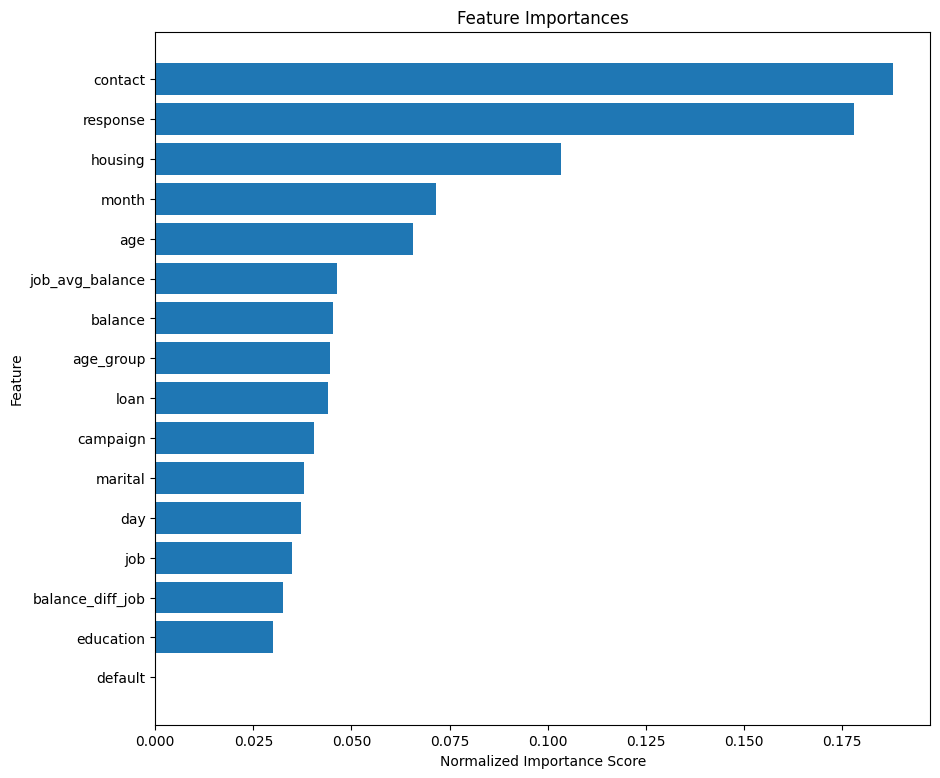

In [52]:
import matplotlib.pyplot as plt

importances = best_xgb_model.feature_importances_


importances = importances / importances.sum()

importance_df = pd.DataFrame({
        'Feature':  X_train.columns,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 9))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importances")
plt.xlabel("Normalized Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [53]:
importance_df

,Feature,Importance
8,contact,0.188140
12,response,0.178158
6,housing,0.103530
10,month,0.071509
0,age,0.065625
14,job_avg_balance,0.046269
5,balance,0.045394
13,age_group,0.044412
7,loan,0.043964
11,campaign,0.040442


In [54]:
important_features_df = importance_df[importance_df['Importance'] > 0.01]

print("Features with Importance > 1%:")
important_features_df

Features with Importance > 1%:


,Feature,Importance
8,contact,0.188140
12,response,0.178158
6,housing,0.103530
10,month,0.071509
0,age,0.065625
14,job_avg_balance,0.046269
5,balance,0.045394
13,age_group,0.044412
7,loan,0.043964
11,campaign,0.040442


In [55]:
important_features_df.Feature.tolist()

['contact',
 'response',
 'housing',
 'month',
 'age',
 'job_avg_balance',
 'balance',
 'age_group',
 'loan',
 'campaign',
 'marital',
 'day',
 'job',
 'balance_diff_job',
 'education']

In [ ]:
pip install shap

SHAP Values Summary (Selected Features)


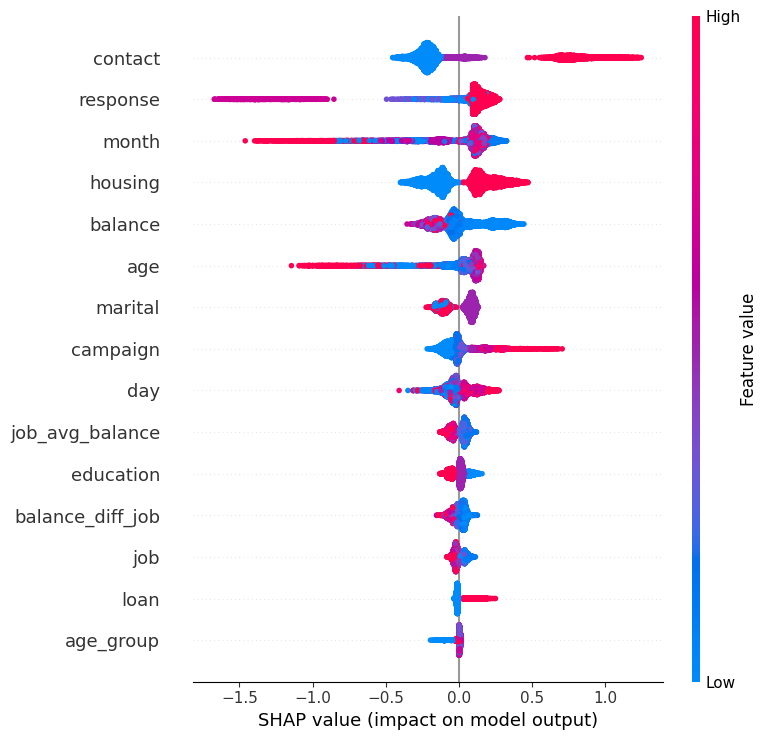

In [57]:
import shap

selected_features = ['contact',
 'response',
 'housing',
 'month',
 'age',
 'job_avg_balance',
 'balance',
 'age_group',
 'loan',
 'campaign',
 'marital',
 'day',
 'job',
 'balance_diff_job',
 'education'
]


explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_train)


shap_df = pd.DataFrame(shap_values, columns=X_train.columns)
shap_selected = shap_df[selected_features]
X_selected = X_train[selected_features]


print("SHAP Values Summary (Selected Features)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_selected.values, X_selected, show=False)
plt.tight_layout()
plt.show()

In [58]:
new_inputs = important_features_df['Feature'].tolist()

new_inputs

['contact',
 'response',
 'housing',
 'month',
 'age',
 'job_avg_balance',
 'balance',
 'age_group',
 'loan',
 'campaign',
 'marital',
 'day',
 'job',
 'balance_diff_job',
 'education']

In [59]:
fin_input = new_data[important_features_df['Feature'].tolist()]
fin_output = data['result']

X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(fin_input, fin_output, test_size=0.3, random_state=42)

In [68]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }

   
    xgb_clf = XGBClassifier(**param)

    auc = cross_val_score(xgb_clf, X_train_fin, y_train_fin, cv=3, scoring='roc_auc').mean()
    
    
    return 2 * auc - 1


study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=1) 

print('Best trial:')
best_params = study.best_params
print('  Best Gini: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model_fin = XGBClassifier(**best_params, random_state=42)

[I 2026-04-03 15:36:34,323] A new study created in memory with name: no-name-35ed883d-2714-418a-af49-03c3b12641da
C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:36:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:36:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:36:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-04-03 15:36:37,873] Trial 0 finished with value: 0.5638938526660882 and parameters: {'n_estimators': 878, 'lea

Best trial:
  Best Gini: 0.564
  Params:  {'n_estimators': 878, 'learning_rate': 0.025401341588887207, 'max_depth': 3, 'gamma': 1.4249284315229173e-05, 'subsample': 0.7081202258409547, 'colsample_bytree': 0.6326416701511824}


In [69]:
train_and_evaluate_model('XGB opitimized for selected features', best_xgb_model_fin, X_train_fin, y_train_fin, X_test_fin, y_test_fin)

Model Performance for XGB opitimized for selected features
Train Gini prob is 67.7046047413175
              precision    recall  f1-score   support

           0       0.79      0.49      0.61      2803
           1       0.80      0.94      0.87      6206

    accuracy                           0.80      9009
   macro avg       0.80      0.72      0.74      9009
weighted avg       0.80      0.80      0.79      9009

[[1382 1421]
 [ 373 5833]]
Model Performance for XGB opitimized for selected features
Test Gini prob is 55.873651135855425
              precision    recall  f1-score   support

           0       0.76      0.45      0.56      1164
           1       0.80      0.94      0.86      2697

    accuracy                           0.79      3861
   macro avg       0.78      0.69      0.71      3861
weighted avg       0.78      0.79      0.77      3861

[[ 521  643]
 [ 169 2528]]


[0.677046047413175, 0.5587365113585543]